## Métricas de Ajuste para Modelos de Classificação

* Matriz de confusão
* Acurácia
* Precisão
* Recall
* Curva ROC

O objetivo principal é tirar a subjetividade da visualização gráfica sobre os modelos e quantificar o aprendizado de máquina a partir de estatísticas para definir qual o melhor modelo para responder ao problema.

# Ajustando a tabela

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/dados_comunidade.csv')
df

,Carimbo de data/hora,Como conheceu o Téo Me Why?,Quantos cursos acompanhou do Téo Me Why?,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,Estado que mora atualmente,Área de Formação,Tempo que atua na área de dados,Posição da cadeira (senioridade),Você se considera uma pessoa feliz?
0,12/06/2025 10:59:27,LinkedIn,0,Sim,Não,Sim,Sim,Sim,Não,34,MG,Exatas,Mais de 4 anos,Sênior,Sim
1,12/06/2025 10:59:34,Twitch,Mais que 3,Sim,Sim,Sim,Não,Não,Sim,26,MG,Exatas,Não atuo,Iniciante,Sim
2,12/06/2025 10:59:36,YouTube,Mais que 3,Sim,Sim,Sim,Sim,Sim,Sim,39,SC,Exatas,De 1 ano a 2 anos,Júnior,Sim
3,12/06/2025 10:59:37,YouTube,Mais que 3,Sim,Sim,Sim,Sim,Sim,Não,27,SP,Exatas,Mais de 4 anos,Pleno,Sim
4,12/06/2025 10:59:41,Twitch,2,Sim,Sim,Sim,Sim,Não,Não,29,CE,Exatas,De 1 ano a 2 anos,Pleno,Sim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,13/06/2025 11:23:48,Amigos,2,Sim,Sim,Sim,Não,Sim,Não,33,SC,Humanas,de 2 anos a 4 anos,Júnior,Sim
178,13/06/2025 11:41:05,Twitch,Mais que 3,Sim,Sim,Sim,Sim,Sim,Sim,32,PR,Biológicas,Mais de 4 anos,Sênior,Sim
179,13/06/2025 20:45:50,Twitter / X,1,Sim,Sim,Sim,Sim,Não,Não,39,SP,Exatas,Não atuo,Iniciante,Não
180,14/06/2025 18:09:20,LinkedIn,1,Sim,Não,Sim,Não,Não,Não,25,SP,Exatas,De 1 ano a 2 anos,Pleno,Não


In [3]:
df = df.replace({
    'Sim' : 1, 'Não' : 0
})
df

,Carimbo de data/hora,Como conheceu o Téo Me Why?,Quantos cursos acompanhou do Téo Me Why?,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,Estado que mora atualmente,Área de Formação,Tempo que atua na área de dados,Posição da cadeira (senioridade),Você se considera uma pessoa feliz?
0,12/06/2025 10:59:27,LinkedIn,0,1,0,1,1,1,0,34,MG,Exatas,Mais de 4 anos,Sênior,1
1,12/06/2025 10:59:34,Twitch,Mais que 3,1,1,1,0,0,1,26,MG,Exatas,Não atuo,Iniciante,1
2,12/06/2025 10:59:36,YouTube,Mais que 3,1,1,1,1,1,1,39,SC,Exatas,De 1 ano a 2 anos,Júnior,1
3,12/06/2025 10:59:37,YouTube,Mais que 3,1,1,1,1,1,0,27,SP,Exatas,Mais de 4 anos,Pleno,1
4,12/06/2025 10:59:41,Twitch,2,1,1,1,1,0,0,29,CE,Exatas,De 1 ano a 2 anos,Pleno,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,13/06/2025 11:23:48,Amigos,2,1,1,1,0,1,0,33,SC,Humanas,de 2 anos a 4 anos,Júnior,1
178,13/06/2025 11:41:05,Twitch,Mais que 3,1,1,1,1,1,1,32,PR,Biológicas,Mais de 4 anos,Sênior,1
179,13/06/2025 20:45:50,Twitter / X,1,1,1,1,1,0,0,39,SP,Exatas,Não atuo,Iniciante,0
180,14/06/2025 18:09:20,LinkedIn,1,1,0,1,0,0,0,25,SP,Exatas,De 1 ano a 2 anos,Pleno,0


In [4]:
dummys_vars = [
'Como conheceu o Téo Me Why?',
'Quantos cursos acompanhou do Téo Me Why?',
'Estado que mora atualmente',
'Área de Formação',
'Tempo que atua na área de dados',
'Posição da cadeira (senioridade)']

df_dummies = pd.get_dummies(df[dummys_vars]).astype(int)
df_dummies.head()

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Tempo que atua na área de dados_de 2 anos a 4 anos,Posição da cadeira (senioridade)_C-Level,Posição da cadeira (senioridade)_Coordenação,Posição da cadeira (senioridade)_Diretoria,Posição da cadeira (senioridade)_Especialista,Posição da cadeira (senioridade)_Gerência,Posição da cadeira (senioridade)_Iniciante,Posição da cadeira (senioridade)_Júnior,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior
0,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [5]:
num_vars = [
'Curte games?',
'Curte futebol?',
'Curte livros?',
'Curte jogos de tabuleiro?',
'Curte jogos de fórmula 1?',
'Curte jogos de MMA?',
'Idade' ]

df[num_vars]

,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade
0,1,0,1,1,1,0,34
1,1,1,1,0,0,1,26
2,1,1,1,1,1,1,39
3,1,1,1,1,1,0,27
4,1,1,1,1,0,0,29
...,...,...,...,...,...,...,...
177,1,1,1,0,1,0,33
178,1,1,1,1,1,1,32
179,1,1,1,1,0,0,39
180,1,0,1,0,0,0,25


In [6]:
df_analise = df_dummies.copy()
df_analise[num_vars] = df[num_vars].copy()
df_analise[num_vars] = df_analise[num_vars].astype(int)
df_analise['feliz'] = df['Você se considera uma pessoa feliz?'].copy().astype(int)

df_analise

,Como conheceu o Téo Me Why?_Amigos,Como conheceu o Téo Me Why?_Instagram,Como conheceu o Téo Me Why?_LinkedIn,Como conheceu o Téo Me Why?_Outra rede social,Como conheceu o Téo Me Why?_Twitch,Como conheceu o Téo Me Why?_Twitter / X,Como conheceu o Téo Me Why?_YouTube,Quantos cursos acompanhou do Téo Me Why?_0,Quantos cursos acompanhou do Téo Me Why?_1,Quantos cursos acompanhou do Téo Me Why?_2,...,Posição da cadeira (senioridade)_Pleno,Posição da cadeira (senioridade)_Sênior,Curte games?,Curte futebol?,Curte livros?,Curte jogos de tabuleiro?,Curte jogos de fórmula 1?,Curte jogos de MMA?,Idade,feliz
0,0,0,1,0,0,0,0,1,0,0,...,0,1,1,0,1,1,1,0,34,1
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,0,0,1,26,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,1,1,39,1
3,0,0,0,0,0,0,1,0,0,0,...,1,0,1,1,1,1,1,0,27,1
4,0,0,0,0,1,0,0,0,0,1,...,1,0,1,1,1,1,0,0,29,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,1,0,0,0,0,0,0,0,0,1,...,0,0,1,1,1,0,1,0,33,1
178,0,0,0,0,1,0,0,0,0,0,...,0,1,1,1,1,1,1,1,32,1
179,0,0,0,0,0,1,0,0,1,0,...,0,0,1,1,1,1,0,0,39,0
180,0,0,1,0,0,0,0,0,1,0,...,1,0,1,0,1,0,0,0,25,0


In [7]:
df_analise.to_csv('../data/abt_comunidade.csv', sep=';', index=False)

# Criando os Modelos

In [8]:
from sklearn import tree

In [9]:
features = df_analise.columns[:-1].tolist()

X = df_analise[features]
y = df_analise['feliz']

In [10]:
arvore = tree.DecisionTreeClassifier(random_state=42,
                                      min_samples_leaf=5)

arvore.fit(X, y)

,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
arv_predict = arvore.predict(X)
arv_predict

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1])

In [12]:
df_predict = df_analise[['feliz']]
df_predict['arv_predict'] = arv_predict
df_predict

,feliz,arv_predict
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
177,1,1
178,1,1
179,0,0
180,0,0


# Matriz de Confusão

In [13]:
pd.crosstab(df_predict['feliz'], df_predict['arv_predict'])

arv_predict,0,1
feliz,,
0,16,19
1,6,141


* Verdadeiro Negativo (V.N.) = (0,0)
* Falso Negativo (F.N.) = (0,1)
* Verdadeiro Positivo (V.P.) = (1,1)
* Falso Positivo (F.P.) = (1,0)

# Acurácia

(Verdadeiro Negativo + Verdadeiro Positivo) / Total

In [14]:
pct_predict = (df_predict['feliz'] == df_predict['arv_predict']).mean()

print(f'O algoritmo de árvore teve precisão de {pct_predict*100:.2f}% na previsão')

O algoritmo de árvore teve precisão de 86.26% na previsão


# Precisão

* Verdadeiro Positivo / (Verdadeiro Positivo + Falso Positivo)

In [15]:
vp = pd.crosstab(df_predict['feliz'], df_predict['arv_predict'])[1][1]
fp = pd.crosstab(df_predict['feliz'], df_predict['arv_predict'])[1][0]

precision = vp / (vp + fp)

print(f'A precisão do modelo é de {precision*100:.2f}%')

A precisão do modelo é de 88.12%


# Recall

A quantidade de predições corretas comparado ao número total de valores positivos (Qual a minha retenção do valor positivo ?)

* Verdadeiro Positivo / (Falso Positivo + Verdadeiro Positivo)

In [16]:
fn = pd.crosstab(df_predict['feliz'], df_predict['arv_predict'])[0][1]

recall = vp / (fn + vp)

print(f'A sensibilidade do modelo é de {recall*100:.2f}%')


A sensibilidade do modelo é de 95.92%


# Especificidade

A quantidade de predições corretas comparado ao número total de valores negativos (Qual a minha retenção do valor negativo ?)

* Verdadeiro Negativo / (Falso Positivo + Verdadeiro Negativo)

In [17]:
vn = pd.crosstab(df_predict['feliz'], df_predict['arv_predict'])[0][0]

especificidade = vn / (vn + fp)

print(f'O modelo possui especificidade de {especificidade*100:.2f}%')

O modelo possui especificidade de 45.71%


# Usando as métricas do sklearn

In [18]:
from sklearn import metrics

In [19]:
arv_proba = arvore.predict_proba(X)[:,1]
df_predict['arv_proba'] = arv_proba
df_predict

,feliz,arv_predict,arv_proba
0,1,1,0.714286
1,1,1,0.750000
2,1,1,0.857143
3,1,1,0.857143
4,1,1,1.000000
...,...,...,...
177,1,1,0.600000
178,1,1,0.600000
179,0,0,0.285714
180,0,0,0.400000


In [20]:
#Acurácia
acc_arv = metrics.accuracy_score(df_predict['feliz'], df_predict['arv_predict'])
print(acc_arv)

# Precisão
prec_arv = metrics.precision_score(df_predict['feliz'], df_predict['arv_predict'])
print(prec_arv)

# Recall
recall_arv = metrics.recall_score(df_predict['feliz'], df_predict['arv_predict'])
print(recall_arv)

0.8626373626373627
0.88125
0.9591836734693877


In [21]:
# Curva ROC
roc_arv = metrics.roc_curve(df_predict['feliz'], df_predict['arv_proba'])

# AUC
roc_auc_arv = metrics.roc_auc_score(df_predict['feliz'], df_predict['arv_proba'])
roc_auc_arv

0.9091350826044703

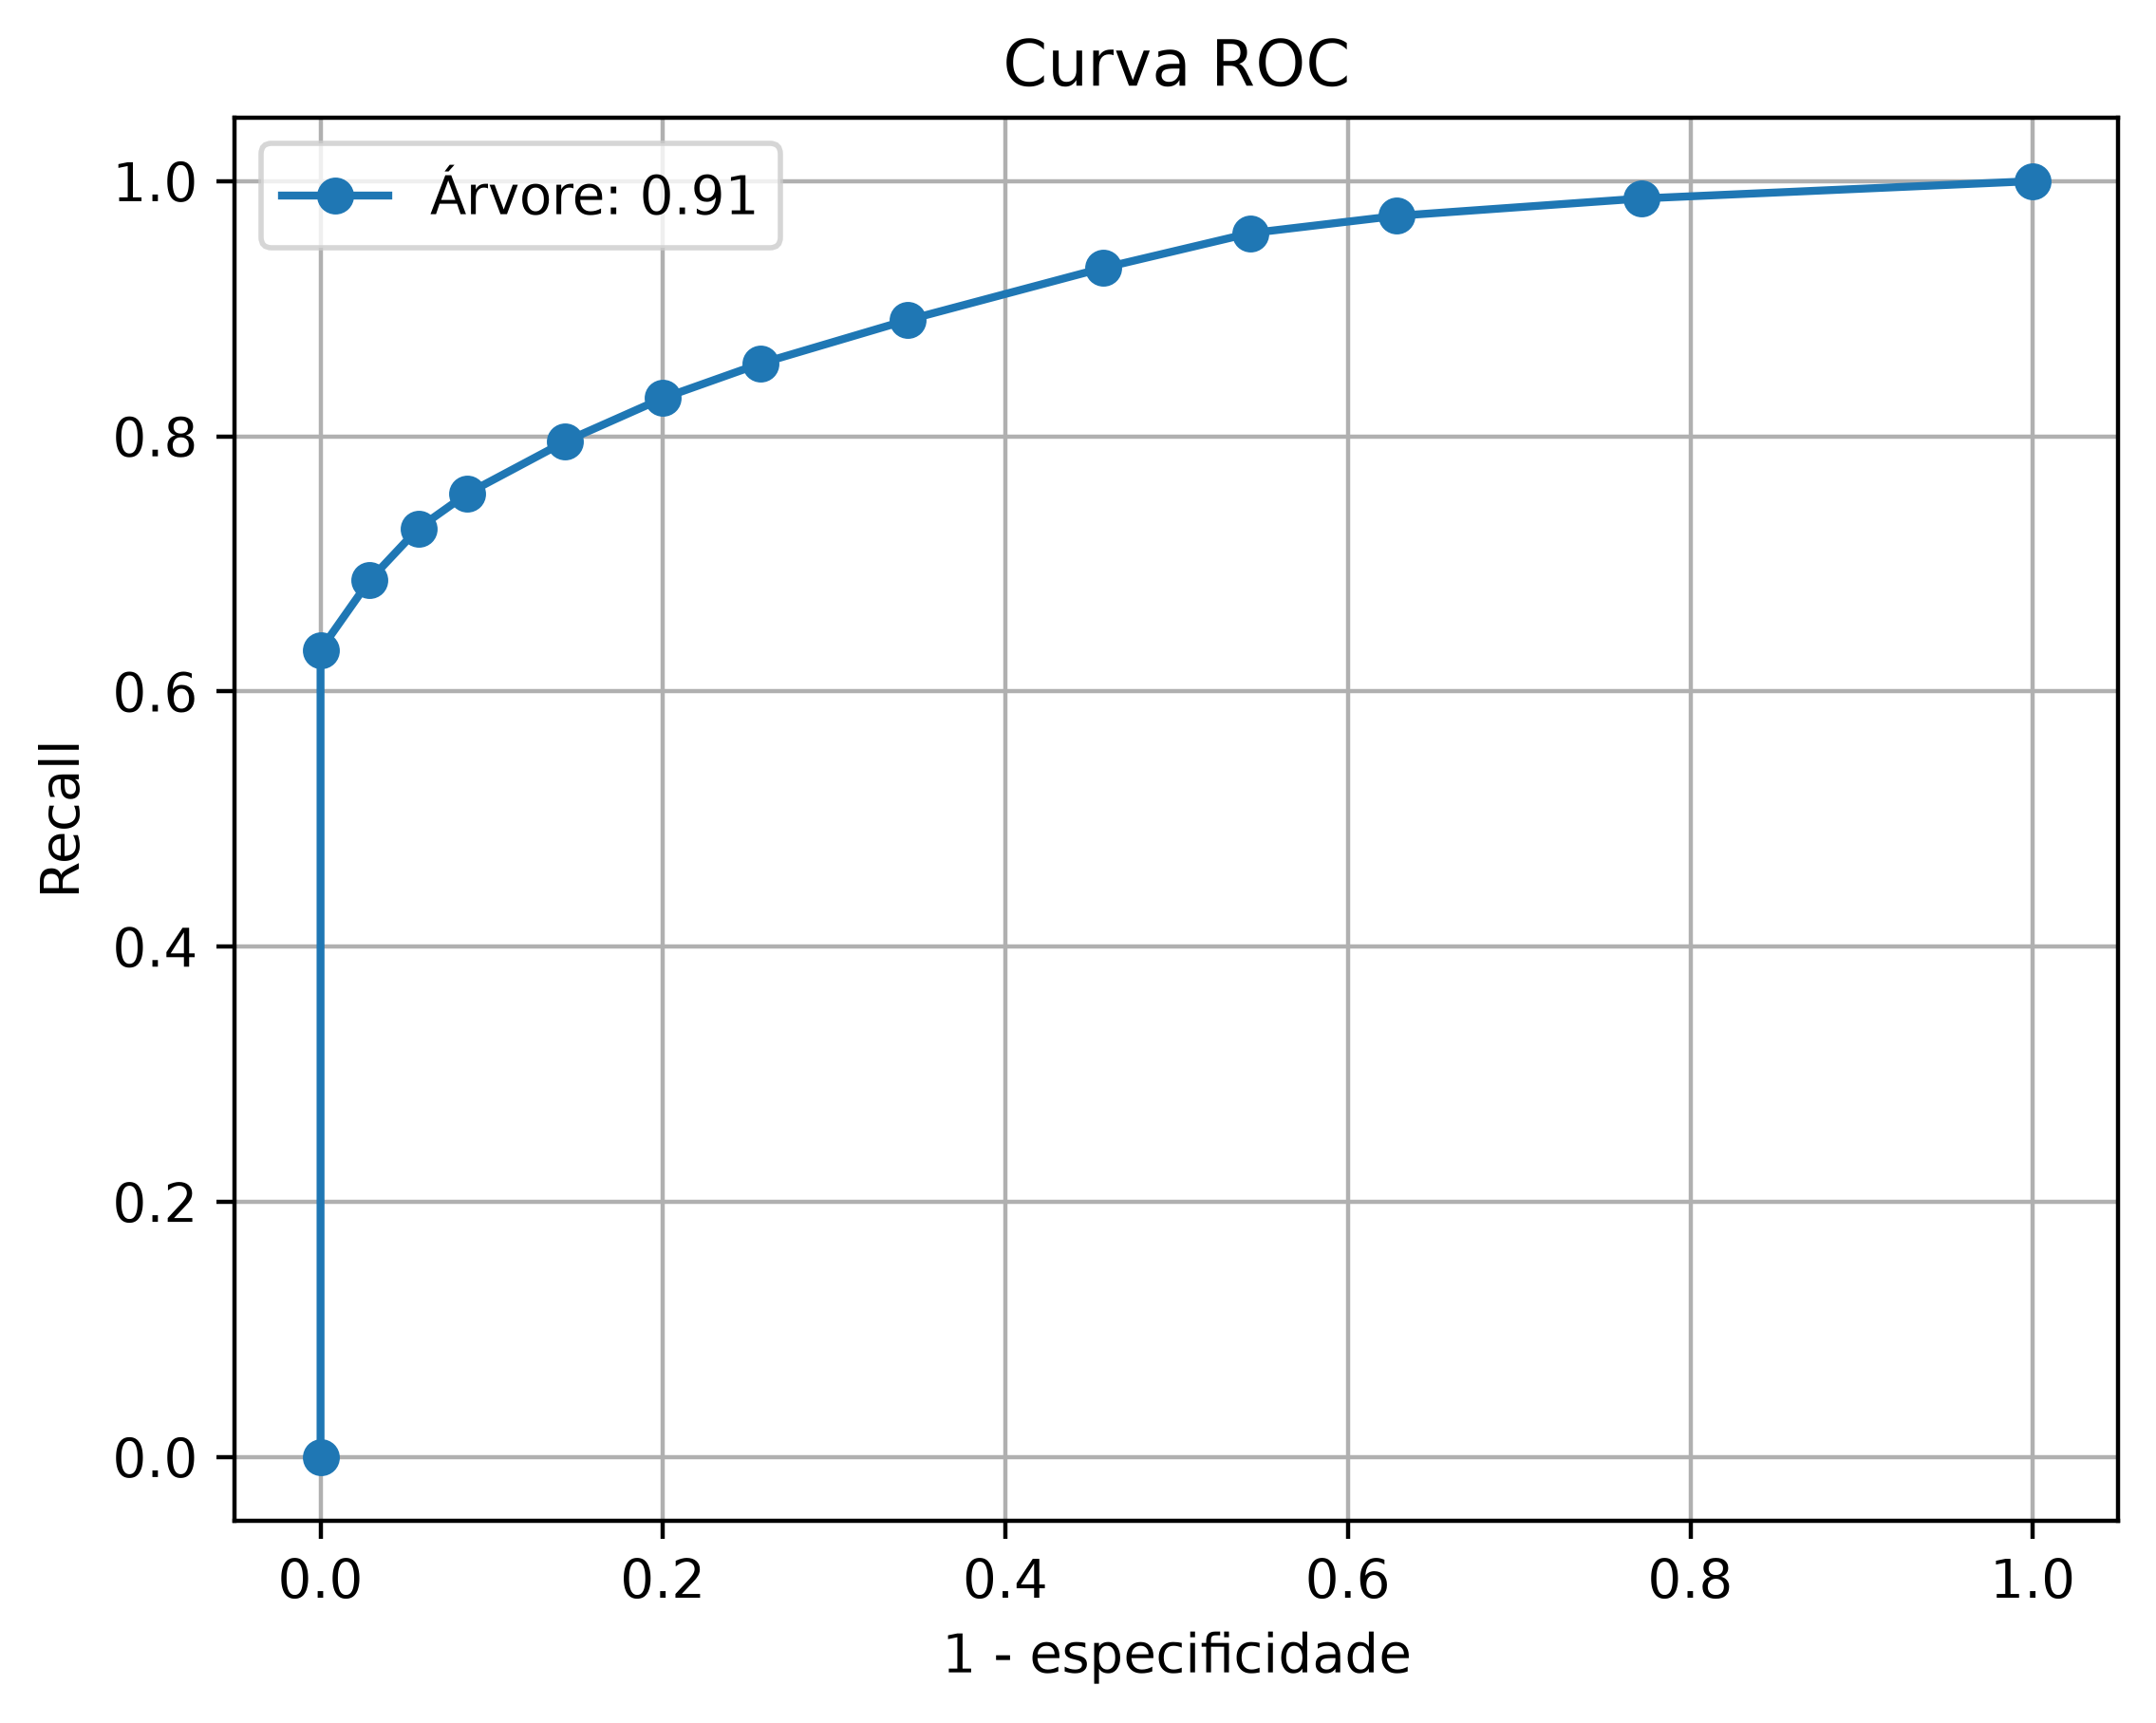

In [22]:
import matplotlib.pyplot as plt

plt.figure(dpi=400)

plt.plot(roc_arv[0], roc_arv[1], 'o-')
plt.grid(True)
plt.title('Curva ROC')
plt.xlabel('1 - especificidade')
plt.ylabel('Recall')

plt.legend([f"Árvore: {roc_auc_arv:.2f}"])